# EnKF assimilation experiments

Twin data-assimilation experiments on the 2D QG model. We assimilate the
observations sampled in `02_sample_observations.ipynb` into an ensemble started
from the (offset) **control** background, using a stochastic Ensemble Kalman
Filter (`EnKF.py`) driven by the `Experiment` class (`Experiment.py`).

The point of the study is the two knobs that make an EnKF work at small ensemble
size:

* **Inflation** (`gamma`): a small ensemble systematically under-estimates its
  own spread; multiplicative inflation re-scales the forecast perturbations to
  compensate. Too little → filter divergence; too much → noisy analyses.
* **Localization** (`loc`): with few members, covariances between distant points
  are dominated by sampling noise. A Gaspari-Cohn taper zeroes far-field
  covariances, which both removes that noise and raises the effective rank of
  the update. Distances are on the doubly-periodic torus.

Baseline to beat: the free-running control, whose error grows at the rate we
measured in notebook 02.

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline

from QG_2D import QG2D, _save_netcdf
from Experiment import Experiment
from EnKF import gaspari_cohn

DT = 0.01                       # integration step (matches notebook 02)

## Load the data from notebook 02

We need `truth.nc`, `control.nc`, and the observation files under `da_data/`.
If they are missing (e.g. notebook 02 hasn't been run in this checkout), a short
twin set is generated on the fly so this notebook is self-contained.

In [17]:
def _generate_small(n_cycles=25, obs_every=24, seed=42):
    P = dict(N=64, beta=0.0, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4)
    m = QG2D(**P)
    qh = np.fft.fft2(m.random_ic(seed=seed, amp=2.0))
    for _ in range(int(40 / DT)):
        qh = m.step(qh, DT)
    q0 = np.real(np.fft.ifft2(qh)); clim = q0.std()
    d = m.random_ic(seed=7, amp=1.0); d *= 0.05 * clim / d.std()
    win = n_cycles * obs_every * DT
    control = m.run(q0,     tf=win, dt=DT, spinup=0, store_every=obs_every, path="da_data/control.nc")
    truth   = m.run(q0 + d, tf=win, dt=DT, spinup=0, store_every=obs_every, path="da_data/truth.nc")
    sig = 0.10 * float(truth.q.std()); rng = np.random.default_rng(0)
    N = P["N"]; times = truth.time.values
    for frac, path in [(1.0, "da_data/obs_full.nc"), (0.25, "da_data/obs_sparse.nc")]:
        mask = np.zeros(N * N, bool)
        if frac >= 1: mask[:] = True
        else: mask[rng.choice(N * N, int(frac * N * N), replace=False)] = True
        mask = mask.reshape(N, N)
        obs = np.where(mask[None], truth.q.values + rng.normal(0, sig, truth.q.shape), np.nan)
        ds = xr.Dataset({"obs": (("time","y","x"), obs), "mask": (("y","x"), mask.astype("i1"))},
                        coords={"time": times, "y": truth.y, "x": truth.x},
                        attrs={**P, "sigma_obs": sig, "dt_obs": obs_every*DT, "coverage": float(mask.mean())})
        _save_netcdf(ds, path)

os.makedirs("da_data", exist_ok=True)
if not all(os.path.exists(f"da_data/{f}.nc") for f in ["truth","control","obs_full","obs_sparse"]):
    print("da_data incomplete -> generating a short twin set ...")
    _generate_small()

truth      = QG2D.load("da_data/truth.nc")
control    = QG2D.load("da_data/control.nc")
obs_full   = QG2D.load("da_data/obs_full.nc")
obs_sparse = QG2D.load("da_data/obs_sparse.nc")

model_params = {k: truth.attrs[k] for k in ["N","L","beta","mu","nu","p","A","k_f"]}
sigma_obs = float(obs_sparse.attrs["sigma_obs"])
clim = float(truth["q"].std())
x0_bg = control["q"].isel(time=0).values          # offset background
print("stored obs times:", truth.sizes["time"], "| sigma_obs:", round(sigma_obs,3),
      "| clim:", round(clim,3), "| dt_obs:", obs_sparse.attrs["dt_obs"])

stored obs times: 2401 | sigma_obs: 0.326 | clim: 3.261 | dt_obs: 0.24


## Experiment settings and a cached runner

We use a modest ensemble and a slice of the available cycles so the notebook
runs quickly; raise `NENS` / `NC` for production. Each configuration is cached.

In [ ]:
NENS = 16
NC   = min(15, truth.sizes["time"] - 1)      # cycles to assimilate

_cache = {}
def run_exp(obs, gamma, loc, nens=NENS, nc=NC):
    key = (obs.attrs["coverage"], gamma, loc, nens, nc)
    if key not in _cache:
        e = Experiment(model_params, truth, obs,
                       dict(nens=nens, dt=DT, gamma=gamma, loc=loc, init_spread=0.1))
        _cache[key] = e.assimilate(ncycles=nc, x0=x0_bg, progress=True)
    return _cache[key]

# free-running baseline (no assimilation): control vs truth
e0 = Experiment(model_params, truth, obs_sparse, dict(nens=2, dt=DT))
free_rmse = e0.free_run_rmse(control, ncycles=NC)
tt = truth["time"].values[:NC+1]

## Experiment A — EnKF vs the free run

A tuned sparse-observation EnKF (inflation + localization) against the
free-running control. The analysis error should drop far below the free run and
settle near — even below — the observation error, because the filter fuses many
noisy observations.

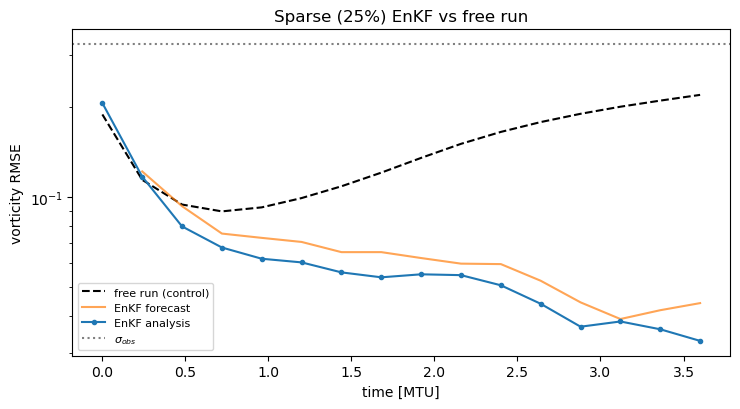

In [20]:
rA = run_exp(obs_sparse, gamma=1.1, loc=1.0)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(tt, free_rmse, "k--", label="free run (control)")
ax.semilogy(rA["time"], rA["rmse_f"], "-", color="C1", alpha=0.7, label="EnKF forecast")
ax.semilogy(rA["time"], rA["rmse_a"], "-o", ms=3, color="C0", label="EnKF analysis")
ax.axhline(sigma_obs, color="gray", ls=":", label=r"$\sigma_{obs}$")
ax.set_xlabel("time [MTU]"); ax.set_ylabel("vorticity RMSE")
ax.set_title("Sparse (25%) EnKF vs free run"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Experiment B — inflation

Sweep the inflation factor at fixed localization. Without inflation the small
ensemble under-spreads and the analysis drifts (or diverges); a little inflation
fixes it; too much re-injects noise. We also track the analysis spread to show
the collapse.

assimilating:   0%|          | 0/15 [00:00<?, ?it/s]

assimilating:   0%|          | 0/15 [00:00<?, ?it/s]

assimilating:   0%|          | 0/15 [00:00<?, ?it/s]

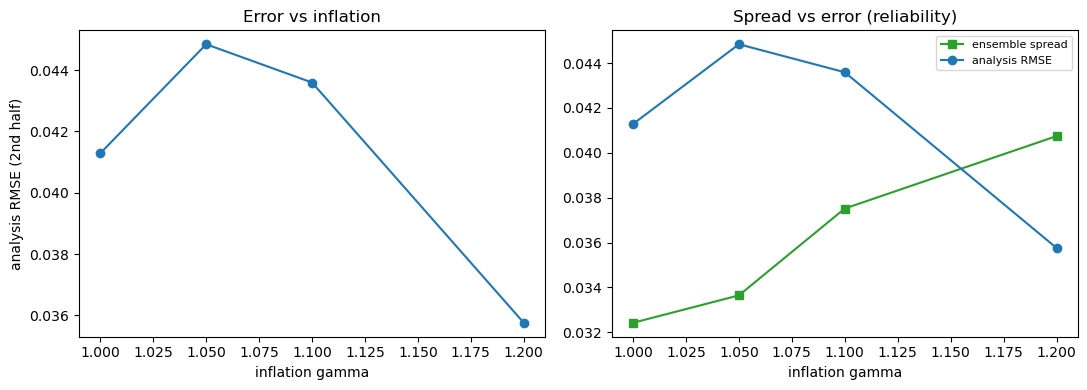

best gamma: 1.2


In [21]:
gammas = [1.0, 1.05, 1.1, 1.2]
mean_rmse, mean_spread = [], []
for g in gammas:
    r = run_exp(obs_sparse, gamma=g, loc=1.0)
    half = slice(len(r["time"])//2, None)
    mean_rmse.append(float(r["rmse_a"].isel(time=half).mean()))
    mean_spread.append(float(r["spread_a"].isel(time=half).mean()))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(gammas, mean_rmse, "o-"); ax[0].set_xlabel("inflation gamma")
ax[0].set_ylabel("analysis RMSE (2nd half)"); ax[0].set_title("Error vs inflation")
ax[1].plot(gammas, mean_spread, "s-", color="C2", label="ensemble spread")
ax[1].plot(gammas, mean_rmse, "o-", color="C0", label="analysis RMSE")
ax[1].set_xlabel("inflation gamma"); ax[1].set_title("Spread vs error (reliability)")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print("best gamma:", gammas[int(np.argmin(mean_rmse))])

## Experiment C — localization

**What localization does.** With a small ensemble, sample covariances between
distant points are dominated by noise: an observation then spuriously updates
far-away parts of the state. Localization suppresses this by multiplying each
covariance entry by a distance-based weight $\rho_{ij}$ (a Schur / element-wise
product), $\mathrm{cov}_{ij}\to\rho_{ij}\,\mathrm{cov}_{ij}$.

**Hard cutoff vs Gaspari-Cohn.** The simplest choice (used in the Lorenz-96
reference) is a *hard cutoff*: keep the covariance unchanged within a radius and
set it to zero beyond it — a step function $\rho(d)=1$ for $d\le$ loc, else
$0$. That abrupt jump is unphysical and injects artificial structure right at
the boundary. **Gaspari-Cohn** replaces the step with a smooth bell: $\rho=1$ at
$d=0$, tapering gradually down to *exactly* zero at $d=2c$ (with $c=$ `loc`).
So nearby covariances are kept almost fully, moderate-distance ones are damped
(e.g. $\times 0.5$), and far ones are removed — a dimmer instead of an on/off
switch. It is also a valid (positive-definite) correlation function, so the
localized matrix stays a proper covariance. In code this is the difference
between `if dist > loc: cov = 0` and `cov = cov * gaspari_cohn(dist, loc)`.

The left panel below shows the taper $g(d;c)$ itself (its two polynomial
branches on $[0,c]$ and $[c,2c]$, zero beyond); the right panel compares no
localization with two length scales. At this ensemble size localization is
essential, and there is an optimal `loc` — too small starves the update of
useful correlations, too large lets the noise back in.

assimilating:   0%|          | 0/15 [00:00<?, ?it/s]

assimilating:   0%|          | 0/15 [00:00<?, ?it/s]

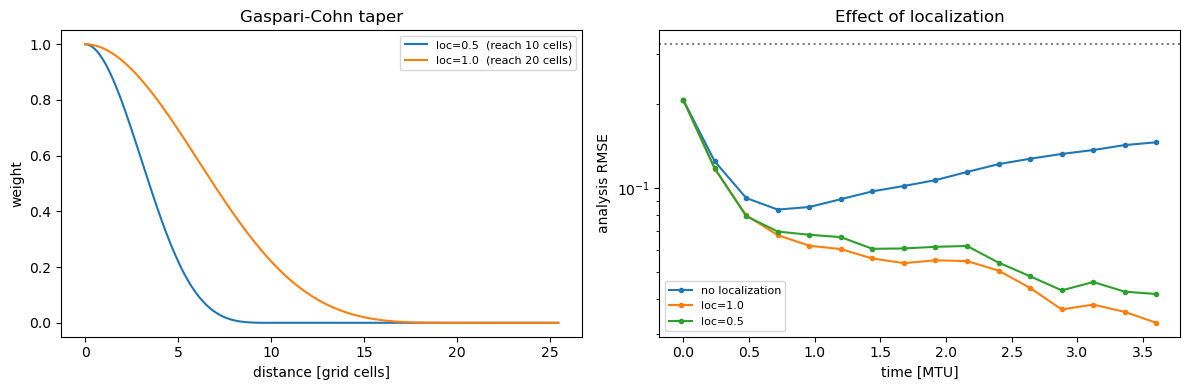

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# the taper itself, with distance shown in grid cells
dx = model_params["L"] / model_params["N"]     # grid spacing (physical units per cell)
d = np.linspace(0, 2.5, 200)
for c in [0.5, 1.0]:
    ax[0].plot(d / dx, gaspari_cohn(d, c), label=f"loc={c}  (reach {2*c/dx:.0f} cells)")
ax[0].set_xlabel("distance [grid cells]"); ax[0].set_ylabel("weight")
ax[0].set_title("Gaspari-Cohn taper"); ax[0].legend(fontsize=8)

for loc, lab in [(None, "no localization"), (1.0, "loc=1.0"), (0.5, "loc=0.5")]:
    r = run_exp(obs_sparse, gamma=1.1, loc=loc)
    ax[1].semilogy(r["time"], r["rmse_a"], "-o", ms=3, label=lab)
ax[1].axhline(sigma_obs, color="gray", ls=":")
ax[1].set_xlabel("time [MTU]"); ax[1].set_ylabel("analysis RMSE")
ax[1].set_title("Effect of localization"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## Experiment D — observation coverage

Full (100%) vs sparse (25%) networks, both tuned. More observations → lower
analysis error, but the sparse network already tracks the truth well.

assimilating:   0%|          | 0/15 [00:00<?, ?it/s]

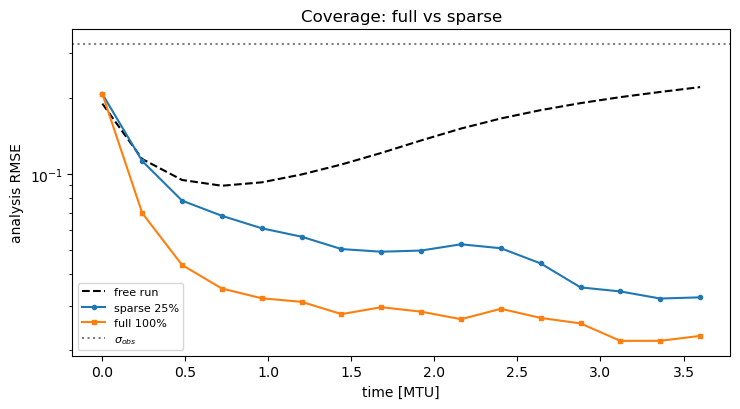

In [12]:
rS = run_exp(obs_sparse, gamma=1.1, loc=1.0)
rF = run_exp(obs_full,   gamma=1.05, loc=1.0)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(tt, free_rmse, "k--", label="free run")
ax.semilogy(rS["time"], rS["rmse_a"], "-o", ms=3, label="sparse 25%")
ax.semilogy(rF["time"], rF["rmse_a"], "-s", ms=3, label="full 100%")
ax.axhline(sigma_obs, color="gray", ls=":", label=r"$\sigma_{obs}$")
ax.set_xlabel("time [MTU]"); ax.set_ylabel("analysis RMSE")
ax.set_title("Coverage: full vs sparse"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Analysis snapshot

Truth, analysis mean, and their difference at the final cycle (sparse EnKF).

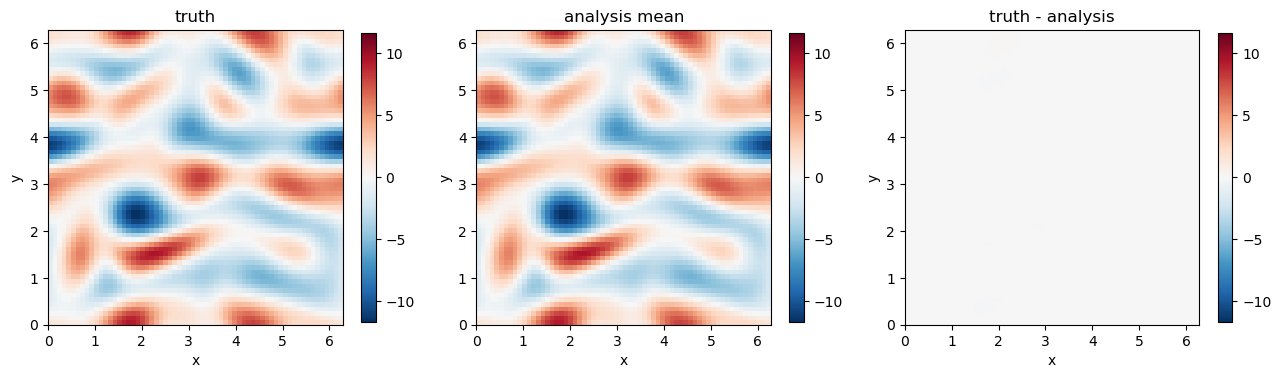

In [23]:
L = model_params["L"]
ti = -1
qt = truth["q"].isel(time=NC).values
qa = rS["xa_mean"].isel(time=ti).values
v = np.abs(qt).max()
ext = [0, L, 0, L]

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, f, t in zip(ax, [qt, qa, qt - qa], ["truth", "analysis mean", "truth - analysis"]):
    im = a.imshow(f.T, cmap="RdBu_r", origin="lower", extent=ext, vmin=-v, vmax=v)
    a.set_title(t); a.set_xlabel("x"); a.set_ylabel("y")
    fig.colorbar(im, ax=a, shrink=0.8)
fig.tight_layout(); plt.show()

## Storing runs for training data

Alongside the forecast/analysis **mean** fields, every run also stores the
per-grid-point ensemble **spread** (`xf_spread` / `xa_spread`, the standard
deviation across members) -- a compact uncertainty field that can serve as an ML
input, without keeping the full ensemble. Pass `save_path` to write the run
under `da_data/` (all fields float32, zlib-compressed). For the production
dataset, run the dense (100%) observations over all cycles.

stored variables : ['xa_mean', 'xf_mean', 'xa_spread', 'xf_spread', 'rmse_a', 'rmse_f', 'spread_a']
field shape      : (2401, 64, 64) (time, y, x)
saved file size  : 157.43 MB
analysis spread < forecast spread: True


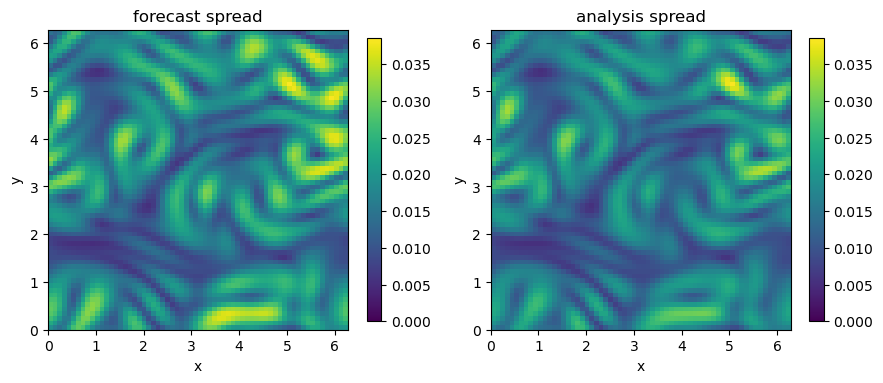

In [24]:
NENS = 40
NC = truth.sizes["time"] - 1          # use all available cycles from the stored truth
run_path = "da_data/enkf_run_long.nc"

if os.path.exists(run_path):
    run_store = QG2D.load(run_path)   # reuse the existing run, do not recompute
else:
    run_store = Experiment(model_params, truth, obs_full,
                           dict(nens=NENS, dt=DT, gamma=1.1, loc=1.0, init_spread=0.1)
                           ).assimilate(ncycles=NC, x0=x0_bg, save_path=run_path)

print("stored variables :", list(run_store.data_vars))
print("field shape      :", run_store.xa_mean.shape, "(time, y, x)")
print("saved file size  : %.2f MB" % (os.path.getsize(run_path) / 1e6))
print("analysis spread < forecast spread:",
      bool(run_store.xa_spread.mean() < run_store.xf_spread.mean()))

# the stored spread fields (ensemble uncertainty) at the last cycle
ti = -1
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
vmax = float(run_store.xf_spread.isel(time=ti).max())
for a, var, title in zip(ax, ["xf_spread", "xa_spread"], ["forecast spread", "analysis spread"]):
    im = a.imshow(run_store[var].isel(time=ti).values.T, origin="lower",
                  extent=[0, L, 0, L], cmap="viridis", vmin=0, vmax=vmax)
    a.set_title(title); a.set_xlabel("x"); a.set_ylabel("y")
    fig.colorbar(im, ax=a, shrink=0.8)
fig.tight_layout(); plt.show()

## Summary & next step (ML augmentation)

The stochastic EnKF drives the analysis error far below the free run; inflation
and localization are both needed at this ensemble size. `Experiment.assimilate`
already accepts `method="ml"` with an `ml_model` exposing
`assimilate(xf_mean, y, obs_idx) -> analysis_mean`, so the next notebook can swap
in a CNN analysis operator (trained to reproduce these EnKF analyses) and compare
it head-to-head against the EnKF on the same observations — the Howard et al.
ML-augmented approach, now on the 2D QG testbed.